<a href="https://colab.research.google.com/github/Yuliia-Safonova/DTA-2026/blob/main/ML/Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Щоб результати були однаковими щоразу (відтворюваність)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)

print("Бібліотеки готові ✅")

Бібліотеки готові ✅


In [2]:
m = 1200
tenure   = np.random.randint(1, 72, m)           # місяців з нами
monthly  = np.random.normal(70, 25, m).clip(15, 150)  # щомісячна оплата, $
support  = np.random.poisson(1.5, m)             # звернень у підтримку за рік
age      = np.random.randint(18, 75, m)          # вік клієнта

# Прихована логіка ризику відтоку (модель її не знає):
risk = (
    -0.05 * tenure        # довше з нами → менший ризик
    + 0.02 * monthly      # дорожчий тариф → трохи більший ризик
    + 0.45 * support      # багато звернень у підтримку → більший ризик
    - 0.01 * age          # старші клієнти трохи лояльніші
    + np.random.normal(0, 0.7, m)
)
prob = 1 / (1 + np.exp(-(risk - 0.5)))   # перетворюємо ризик на ймовірність 0..1
churn = (np.random.rand(m) < prob).astype(int)

df = pd.DataFrame({
    "tenure": tenure, "monthly": monthly.round(1),
    "support": support, "age": age, "churn": churn,
})

print("Частка клієнтів, що пішли:", f"{df['churn'].mean():.1%}")
df.head()

Частка клієнтів, що пішли: 39.3%


,tenure,monthly,support,age,churn
0,52,21.7,1,21,0
1,15,39.8,1,20,0
2,61,43.2,4,73,0
3,21,87.1,0,46,1
4,24,65.9,1,69,1


In [3]:
from sklearn.model_selection import train_test_split

X = df[['tenure', 'monthly', 'support', 'age']] # featurea - ознаки
y = df['churn'] # target - ціль

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Навчальна вибірка:', X_train.shape[0], 'клієнтів')
print('Тестова вибірка:', X_test.shape[0], 'клієнтів')

Навчальна вибірка: 960 клієнтів
Тестова вибірка: 240 клієнтів


In [4]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=3,
    random_state=RANDOM_STATE
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

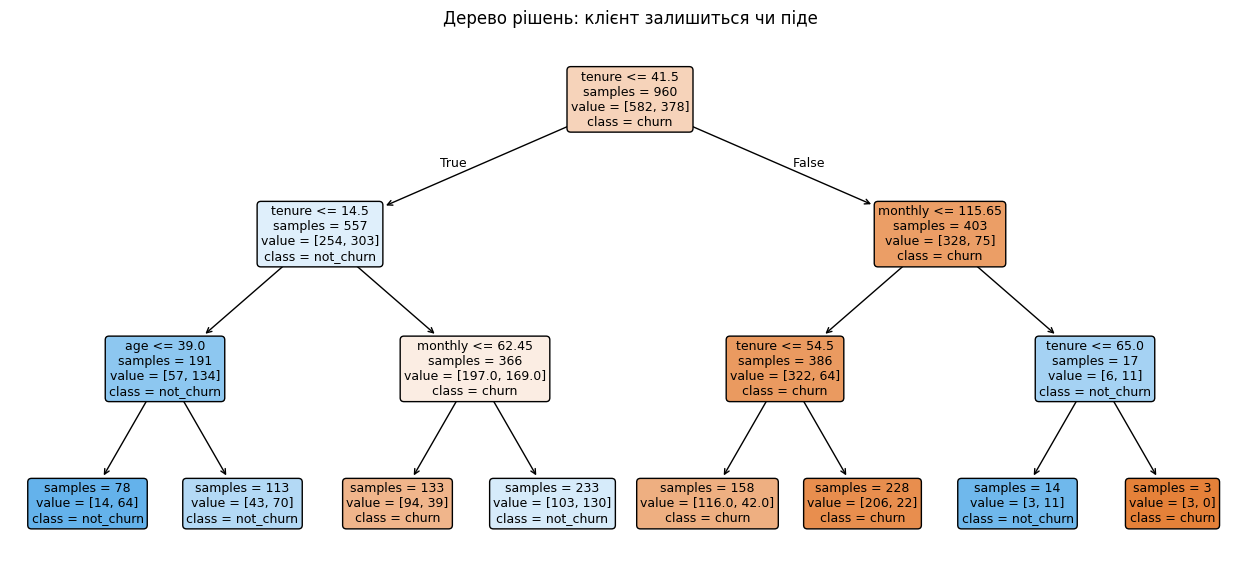

In [5]:
from sklearn.tree import plot_tree

plt.figure(figsize=(16, 7))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=['churn', 'not_churn'],
    filled=True, rounded=True, fontsize=9, impurity=False
)

plt.title('Дерево рішень: клієнт залишиться чи піде')
plt.show()

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy = {acc:.2%}\n')

cm = confusion_matrix(y_test, y_pred)
df_cm = pd.DataFrame(
    cm,
    index=['Насправді залишилися', 'Насправді пішли'],
    columns=['Передбачено залишилися', 'Передбачено пішли']
)

print('Матриця плутанини:')
display(df_cm)

print('\nДетальний звіт по метриках:')
print(classification_report(y_test, y_pred, target_names=['Залишилися', 'Пішли'])) # 0 - залишилися, 1 - пішли

Accuracy = 59.17%

Матриця плутанини:


,Передбачено залишилися,Передбачено пішли
Насправді залишилися,85,61
Насправді пішли,37,57



Детальний звіт по метриках:
              precision    recall  f1-score   support

  Залишилися       0.70      0.58      0.63       146
       Пішли       0.48      0.61      0.54        94

    accuracy                           0.59       240
   macro avg       0.59      0.59      0.59       240
weighted avg       0.61      0.59      0.60       240



 precision = 85 / (85+37) - точність відповіді (стовпчик "Передбачено залишилися")  

 recall = 85 / (85+61) - повнота відповіді (частка відносно всієї вибірки = рядок "Насправді залишилися")  

 f1-score = загальна точність (середнє між precision и recall)  

 support = 146 + 94 = 240 - розмір тестової вибірки

 accuracy = з 240 клієнтів ми вгадали 59%  

 macro avg = середнє арифметичне (0.70 + 0.48) / 2 = 0.59 і т.д  

 weighted avg = середнє зважене (146 з 240), (94 з 240)




# Random Forest Classifier

In [7]:
from sklearn.ensemble import RandomForestClassifier

model_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=RANDOM_STATE
)

model_forest.fit(X_train, y_train)
y_pred_rf = model_forest.predict(X_test) #_rf=RandomForest

print(f"Одне дерево: accuracy = {accuracy_score(y_test, y_pred):.2%}")
print(f"Цілий ліс: accuracy = {accuracy_score(y_test, y_pred_rf):.2%}")

Одне дерево: accuracy = 59.17%
Цілий ліс: accuracy = 64.58%


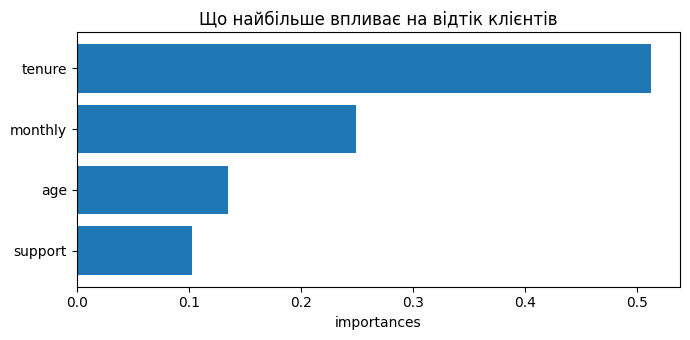

,features,importances
2,support,0.103
3,age,0.135
1,monthly,0.249
0,tenure,0.513


In [8]:
importances = pd.DataFrame({
    'features': X.columns,
    'importances': model_forest.feature_importances_.round(3)
}).sort_values('importances', ascending=True)

plt.figure(figsize=(7, 3.5))
plt.barh(importances['features'], importances['importances'])

plt.title("Що найбільше впливає на відтік клієнтів")
plt.xlabel('importances')

plt.tight_layout()
plt.show()

importances

## Predicting

In [9]:
new_client = pd.DataFrame([{
    'tenure': 3,
    'monthly': 95,
    'support': 5,
    'age': 25
}])

new_client

,tenure,monthly,support,age
0,3,95,5,25


In [10]:
print(f'Ймовірність відтоку: {model_forest.predict_proba(new_client)[0, 1]:.2%}')
# print(f'Рішення: {"ПІДЕ" if model_forest.predict(new_client)[0] == 1 else "ЗАЛИШИТЬСЯ"}')
print(f'Рішення: {"ПІДЕ" if model_forest.predict(new_client)[0] else "ЗАЛИШИТЬСЯ"}')

print('\n------------\n')
print(f'Вирогідність результату: {accuracy_score(y_test, y_pred_rf):.2%}')

Ймовірність відтоку: 88.66%
Рішення: ПІДЕ

------------

Вирогідність результату: 64.58%


In [11]:
# print(f"Рішення: {"ПІДЕ" if model_forest.predict(new_client)[0] else "ЗАЛИШИТЬСЯ"}")
pred_model = model_forest.predict(new_client)[0]
# 1 або 0
# 1 (True) або 0 (False)
if pred_model:
  print("Піде")
else:
  print("Залишиться")
# if pred_model == 1:
#   print("Піде")
# else:
#   print("Залишиться")

Піде
